# 00 — Coleta de Dados
## Brasileirão Série A 2025 — Previsão de Rebaixamento

**Aluno:** Leonardo Feitosa | **UFPB — Ciência de Dados**

---

## Fonte dos Dados

Os dados foram coletados do site **Transfermarkt** (https://www.transfermarkt.com.br) utilizando as bibliotecas **`requests`** e **`BeautifulSoup`** (para requisição HTTP e parsing do HTML), cobrindo todas as temporadas do Brasileirão Série A de **2014 a 2025**.

Para cada temporada foram extraídas informações sobre os 20 clubes participantes, incluindo:
- Tamanho do plantel
- Número de jogadores estrangeiros
- Idade média
- Valor de mercado médio e total

Os **pontos finais** de cada temporada (coluna `Pontos`) também foram coletados via **Python**, raspando a tabela de classificação final do Transfermarkt para cada edição do campeonato. O cruzamento entre pontos e clubes foi realizado com `pandas.merge()`, eliminando qualquer necessidade de planilhas externas ou fórmulas manuais.

Para a temporada de **2025**, os pontos ainda não foram definidos, pois o campeonato está em andamento.

---

## Etapas de Limpeza e Preparação dos Dados

Todas as etapas de limpeza foram implementadas em Python, sem uso de ferramentas externas:

| Etapa | Descrição |
|---|---|
| **1. Normalização de colunas** | `df.columns.str.strip()` remove espaços extras nos nomes das colunas |
| **2. Padronização de nomes de clubes** | Clubes com grafias diferentes ao longo dos anos (`Atlético Paranaense` → `Athletico Paranaense`) e nomes truncados (`Vasco da` → `Vasco da Gama`) são unificados |
| **3. Correção dos rótulos de rebaixamento** | A coluna `Situacao` foi verificada contra as tabelas históricas oficiais do Brasileirão. Cada temporada deve ter exatamente **4 rebaixados** |
| **4. Padronização da variável-alvo** | `Situacao` é consolidada em `Status_bin` binário: **0 = Rebaixado**, **1 = Permaneceu** |
| **5. Tratamento de nulos esperados** | Os 20 registros de 2025 não possuem `Situacao` nem `Pontos` — usados apenas para previsão |
| **6. Verificação de zeros indevidos** | Confirma que nenhum clube de 2014–2024 ficou com 0 pontos por erro de scraping |

In [1]:
# Convencao Transfermarkt para o Brasileirao:
# saison_id = ano - 1  (saison_id=2013 -> temporada 2014, saison_id=2022 -> temporada 2023, etc.)
urls_elenco = {
    ano: f"https://www.transfermarkt.com.br/campeonato-brasileiro-serie-a/startseite/wettbewerb/BRA1/saison_id/{ano - 1}"
    for ano in range(2014, 2026)
}
urls_pontos = {
    ano: f"https://www.transfermarkt.com.br/campeonato-brasileiro-serie-a/tabelle/wettbewerb/BRA1/saison_id/{ano - 1}"
    for ano in range(2014, 2025)
}
print("URLs Elenco (saison_id = ano - 1):")
for ano, url in urls_elenco.items():
    print(f"  {ano}: {url}")
print()
print("URLs Pontos (saison_id = ano - 1):")
for ano, url in urls_pontos.items():
    print(f"  {ano}: {url}")

URLs Elenco (saison_id = ano - 1):
  2014: https://www.transfermarkt.com.br/campeonato-brasileiro-serie-a/startseite/wettbewerb/BRA1/saison_id/2013
  2015: https://www.transfermarkt.com.br/campeonato-brasileiro-serie-a/startseite/wettbewerb/BRA1/saison_id/2014
  2016: https://www.transfermarkt.com.br/campeonato-brasileiro-serie-a/startseite/wettbewerb/BRA1/saison_id/2015
  2017: https://www.transfermarkt.com.br/campeonato-brasileiro-serie-a/startseite/wettbewerb/BRA1/saison_id/2016
  2018: https://www.transfermarkt.com.br/campeonato-brasileiro-serie-a/startseite/wettbewerb/BRA1/saison_id/2017
  2019: https://www.transfermarkt.com.br/campeonato-brasileiro-serie-a/startseite/wettbewerb/BRA1/saison_id/2018
  2020: https://www.transfermarkt.com.br/campeonato-brasileiro-serie-a/startseite/wettbewerb/BRA1/saison_id/2019
  2021: https://www.transfermarkt.com.br/campeonato-brasileiro-serie-a/startseite/wettbewerb/BRA1/saison_id/2020
  2022: https://www.transfermarkt.com.br/campeonato-brasileir

## Coleta dos Dados — `requests` + `BeautifulSoup`

O scraping é feito em duas etapas independentes, ambas acessando o Transfermarkt via HTTP:

### Etapa 1 — Dados de Elenco (por temporada)
Para cada ano de 2014 a 2025, a função `coletar_elenco_temporada(ano)` acessa a página de elencos da Série A e extrai:
- Nome do clube
- Tamanho do plantel
- Número de estrangeiros
- Idade média
- Valor de mercado médio e total

### Etapa 2 — Pontos Finais (classificação)
Para cada ano de 2014 a 2024, a função `coletar_pontos_temporada(ano)` acessa a tabela de classificação e extrai o total de pontos de cada clube. A temporada de **2025** não possui pontos (`NaN`) pois está em andamento.

> **Controle:** A variável `EXECUTAR_COLETA` evita re-executar o scraping a cada abertura do notebook.  
> Os dados já estão salvos em `BASE_FINAL.xlsx`. Altere para `True` apenas para atualizar.

In [2]:
import requests
from bs4 import BeautifulSoup
import unicodedata
import time
import pandas as pd
import os

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0.0.0 Safari/537.36"
    )
}

# Altere para True para re-executar o scraping completo (~10 min)
EXECUTAR_COLETA = True

# Mapeamento Transfermarkt -> nome padronizado.
# Necessario porque startseite (elencos) e tabelle (pontos) usam grafias diferentes.
NOME_MAP = {
    # --- startseite (elencos) ---
    "AA Ponte Preta":            "Ponte Preta",
    "America Mineiro":           "America Mineiro",
    "Athletico Paranaense":      "Athletico Paranaense",
    "Atletico Goianiense":       "Atletico Goianiense",
    "Atletico Mineiro":          "Atletico Mineiro",
    "Avai FC":                   "Avai",
    "Botafogo FR":               "Botafogo",
    "CR Flamengo":               "Flamengo",
    "CR Vasco da Gama":          "Vasco da Gama",
    "CSA":                       "CSA",
    "Ceara SC":                  "Ceara",
    "Chapecoense":               "Chapecoense",
    "Clube Atletico Paranaense": "Athletico Paranaense",
    "Clube do Remo":             "Clube do Remo",
    "Coritiba FC":               "Coritiba",
    "Criciuma EC":               "Criciuma",
    "Cruzeiro EC":               "Cruzeiro",
    "Cuiaba EC":                 "Cuiaba",
    "EC Bahia":                  "Bahia",
    "EC Juventude":              "Juventude",
    "EC Vitoria":                "Vitoria",
    "Figueirense FC":            "Figueirense",
    "Fluminense FC":             "Fluminense",
    "Fortaleza EC":              "Fortaleza",
    "Goias EC":                  "Goias",
    "Gremio FBPA":               "Gremio",
    "Joinville EC":              "Joinville",
    "Mirassol FC":               "Mirassol",
    "Parana Clube":              "Parana",
    "RB Bragantino":             "Bragantino",
    "SC Corinthians":            "Corinthians",
    "SC Internacional":          "Internacional",
    "SE Palmeiras":              "Palmeiras",
    "Santa Cruz FC":             "Santa Cruz",
    "Santos FC":                 "Santos",
    "Sport Recife":              "Sport Recife",
    "Sao Paulo FC":              "Sao Paulo",
    # --- tabelle (pontos) ---
    "America-MG":               "America Mineiro",
    "Athletico-PR":             "Athletico Paranaense",
    "Atletico-GO":              "Atletico Goianiense",
    "Atletico-MG":              "Atletico Mineiro",
    "Atletico-PR":              "Athletico Paranaense",
    "Avai":                     "Avai",
    "Bahia":                    "Bahia",
    "Botafogo":                 "Botafogo",
    "Bragantino":               "Bragantino",
    "Ceara":                    "Ceara",
    "Corinthians":              "Corinthians",
    "Coritiba":                 "Coritiba",
    "Criciuma":                 "Criciuma",
    "Cruzeiro":                 "Cruzeiro",
    "Cuiaba":                   "Cuiaba",
    "Figueirense":              "Figueirense",
    "Flamengo":                 "Flamengo",
    "Fluminense":               "Fluminense",
    "Fortaleza":                "Fortaleza",
    "Goias":                    "Goias",
    "Gremio":                   "Gremio",
    "Internacional":            "Internacional",
    "Joinville":                "Joinville",
    "Juventude":                "Juventude",
    "Palmeiras":                "Palmeiras",
    "Parana":                   "Parana",
    "Ponte Preta":              "Ponte Preta",
    "Santa Cruz":               "Santa Cruz",
    "Santos":                   "Santos",
    "Sport":                    "Sport Recife",
    "Sao Paulo":                "Sao Paulo",
    "Vasco da Gama":            "Vasco da Gama",
    "Vitoria":                  "Vitoria",
}

def normalizar_nome(nome):
    """Remove acentos e aplica NOME_MAP para padronizar o nome do clube."""
    sem_acento = unicodedata.normalize("NFD", str(nome))
    sem_acento = "".join(c for c in sem_acento if unicodedata.category(c) != "Mn")
    return NOME_MAP.get(sem_acento, sem_acento)

print(f"EXECUTAR_COLETA = {EXECUTAR_COLETA}")
print(f"NOME_MAP: {len(NOME_MAP)} entradas carregadas")

EXECUTAR_COLETA = True
NOME_MAP: 70 entradas carregadas


### Função 1 — `coletar_elenco_temporada(ano)`

Acessa a página de elencos do Transfermarkt e extrai: `Clube`, `Plantel`,
`ø Idade`, `Estrangeiros`, `ø Valor de Mercado`, `Valor de Mercado Total`.

In [3]:
def coletar_elenco_temporada(ano: int) -> pd.DataFrame:
    """Raspa dados de elenco do Transfermarkt (startseite).

    Aplica normalizar_nome() para garantir que os nomes fiquem
    padronizados e o merge com a tabela de pontos funcione corretamente.
    """
    url = (
        f"https://www.transfermarkt.com.br/campeonato-brasileiro-serie-a/"
        f"startseite/wettbewerb/BRA1/saison_id/{ano - 1}"
    )
    resp = requests.get(url, headers=HEADERS, timeout=20)
    soup = BeautifulSoup(resp.text, "html.parser")

    tabela = soup.find("table", {"class": "items"})
    if tabela is None:
        print(f"  [AVISO] Tabela nao encontrada para {ano}")
        return pd.DataFrame()

    def _val(td):
        """Converte '€ 3.70 mi.' ou '€ 540 mil' para float em milhões."""
        txt = td.get_text(strip=True)
        em_mil = ("mil" in txt) and ("mi." not in txt)
        txt = (txt.replace("€", "").replace("mi.", "").replace("mil", "")
                  .replace(",", ".").strip())
        val = float(txt) if txt else 0.0
        return round(val / 1000, 4) if em_mil else val

    registros = []
    for tr in tabela.find_all("tr", class_=["odd", "even"]):
        tds = tr.find_all("td")
        if len(tds) < 7:
            continue
        try:
            registros.append({
                "Clube":                  normalizar_nome(tds[1].get_text(strip=True)),
                "Plantel":                int(tds[2].get_text(strip=True) or 0),
                "o Idade":                float(tds[3].get_text(strip=True).replace(",", ".") or 0),
                "Estrangeiros":           int(tds[4].get_text(strip=True) or 0),
                "o Valor de Mercado":     _val(tds[5]),
                "Valor de Mercado Total": _val(tds[6]),
                "Temporada":              ano,
            })
        except (ValueError, IndexError):
            continue

    time.sleep(2)
    return pd.DataFrame(registros)

print("Funcao coletar_elenco_temporada definida.")

Funcao coletar_elenco_temporada definida.


### Função 2 — `coletar_pontos_temporada(ano)`

Acessa a tabela de classificação final e extrai `Clube` e `Pontos`.
Convenção: `saison_id = Temporada - 1` (padrão do Transfermarkt para pontos).

In [4]:
def coletar_pontos_temporada(ano: int) -> pd.DataFrame:
    """Raspa pontos finais e deriva Situacao pela posicao na tabela.

    Convencao Transfermarkt para o Brasileirao:
      saison_id = ano - 1  (saison_id=2023 retorna dados da temporada 2024 do Brasileirao)
      Temporada armazenada = ano (ex: saison_id=2023 -> Temporada=2024)

    Posicao  1-4  -> Top4
    Posicao  5-16 -> SerieA
    Posicao 17-20 -> Rebaixado (sera sobrescrito pela celula de correcoes)
    """
    url = (
        f"https://www.transfermarkt.com.br/campeonato-brasileiro-serie-a/"
        f"tabelle/wettbewerb/BRA1/saison_id/{ano - 1}"
    )
    resp = requests.get(url, headers=HEADERS, timeout=20)
    soup = BeautifulSoup(resp.text, "html.parser")

    tabelas = soup.find_all("table", {"class": "items"})
    tabela = next((t for t in tabelas if len(t.find_all("tr")) > 5), None)
    if tabela is None:
        print(f"  [AVISO] Tabela de pontos nao encontrada para {ano}")
        return pd.DataFrame()

    registros = []
    posicao = 0
    for tr in tabela.find_all("tr")[1:]:
        tds = tr.find_all("td")
        if len(tds) < 3:
            continue
        try:
            clube  = normalizar_nome(tds[2].get_text(strip=True))
            pontos = int(tds[-1].get_text(strip=True) or 0)
            if not clube:
                continue
            posicao += 1
            if posicao <= 4:
                situacao = "Top4"
            elif posicao >= 17:
                situacao = "Rebaixado"
            else:
                situacao = "SerieA"
            registros.append({"Clube": clube, "Pontos": pontos, "Situacao": situacao, "Temporada": ano})
        except (ValueError, IndexError):
            continue

    time.sleep(2)
    return pd.DataFrame(registros)

print("Funcao coletar_pontos_temporada definida.")

Funcao coletar_pontos_temporada definida.


### Etapa 1 — Coleta dos Dados de Elenco (2014–2025)

Executa `coletar_elenco_temporada` para cada ano e salva uma aba por temporada
em `dados/dados_brutos_transfermarkt.xlsx` — exatamente como veio do site.

In [5]:
if EXECUTAR_COLETA:
    caminho_bruto = os.path.join("..", "dados", "dados_brutos_transfermarkt.xlsx")
    frames_elenco = []

    print("=== Coletando elencos (2014-2025) ===")
    with pd.ExcelWriter(caminho_bruto, engine="openpyxl") as writer:
        for ano in range(2014, 2026):
            print(f"  Elenco {ano}...", end=" ")
            df_ano = coletar_elenco_temporada(ano)
            frames_elenco.append(df_ano)
            df_ano.to_excel(writer, sheet_name=f"Elenco_{ano}", index=False)
            print(f"{len(df_ano)} clubes")

    print("\n✓ Salvo: dados_brutos_transfermarkt.xlsx")
    print("  Sheets: Elenco_2014 ... Elenco_2025")
    display(frames_elenco[0].head(5))
else:
    print("EXECUTAR_COLETA = False — etapa ignorada.")

=== Coletando elencos (2014-2025) ===
  Elenco 2014... 20 clubes
  Elenco 2015... 20 clubes
  Elenco 2016... 20 clubes
  Elenco 2017... 20 clubes
  Elenco 2018... 20 clubes
  Elenco 2019... 20 clubes
  Elenco 2020... 20 clubes
  Elenco 2021... 20 clubes
  Elenco 2022... 20 clubes
  Elenco 2023... 20 clubes
  Elenco 2024... 20 clubes
  Elenco 2025... 20 clubes

✓ Salvo: dados_brutos_transfermarkt.xlsx
  Sheets: Elenco_2014 ... Elenco_2025


,Clube,Plantel,o Idade,Estrangeiros,o Valor de Mercado,Valor de Mercado Total,Temporada
0,Sao Paulo,45,24.8,6,3.33,149.65,2014
1,Corinthians,44,24.3,6,1.99,87.55,2014
2,Santos,49,22.6,6,1.50,73.40,2014
3,Atletico Mineiro,55,24.6,2,1.16,63.85,2014
4,Fluminense,43,23.1,2,1.13,48.80,2014


### Etapa 2 — Coleta dos Pontos Finais (2014–2024)

Executa `coletar_pontos_temporada` e adiciona novas abas (`Pontos_XXXX`)
no mesmo arquivo `dados_brutos_transfermarkt.xlsx`.

In [6]:
if EXECUTAR_COLETA:
    frames_pontos = []

    print("=== Coletando pontos finais (2014-2024) ===")
    with pd.ExcelWriter(caminho_bruto, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
        for ano in range(2014, 2025):
            print(f"  Pontos {ano}...", end=" ")
            df_pts = coletar_pontos_temporada(ano)
            frames_pontos.append(df_pts)
            df_pts.to_excel(writer, sheet_name=f"Pontos_{ano}", index=False)
            print(f"{len(df_pts)} clubes")

    print("\n✓ Sheets adicionados: Pontos_2014 ... Pontos_2024")
    display(frames_pontos[0].head(5))
else:
    print("EXECUTAR_COLETA = False — etapa ignorada.")

=== Coletando pontos finais (2014-2024) ===
  Pontos 2014... 20 clubes
  Pontos 2015... 20 clubes
  Pontos 2016... 20 clubes
  Pontos 2017... 20 clubes
  Pontos 2018... 20 clubes
  Pontos 2019... 20 clubes
  Pontos 2020... 20 clubes
  Pontos 2021... 20 clubes
  Pontos 2022... 20 clubes
  Pontos 2023... 20 clubes
  Pontos 2024... 20 clubes

✓ Sheets adicionados: Pontos_2014 ... Pontos_2024


,Clube,Pontos,Situacao,Temporada
0,Cruzeiro,80,Top4,2014
1,Sao Paulo,70,Top4,2014
2,Internacional,69,Top4,2014
3,Corinthians,69,Top4,2014
4,Atletico Mineiro,62,SerieA,2014


### Etapa 3 — Consolidação: Merge Elenco + Pontos → `BASE_FINAL.xlsx`

Une os dois DataFrames pela chave `["Clube", "Temporada"]` (left join).
O ano 2025 não tem pontos — fica com `NaN`, como esperado.
O resultado é salvo em `BASE_FINAL.xlsx` e será limpado nas etapas seguintes.

In [7]:
if EXECUTAR_COLETA:
    df_elenco_total = pd.concat(frames_elenco, ignore_index=True)
    df_pontos_total = pd.concat(frames_pontos, ignore_index=True)

    # Merge por Clube + Temporada — nomes ja normalizados em ambos os DataFrames
    # A coluna Situacao vem da tabela de pontos (derivada da posicao final)
    # 2025: Pontos e Situacao ficam NaN (temporada em andamento) — correto
    df_bruto = df_elenco_total.merge(
        df_pontos_total[["Clube", "Temporada", "Pontos", "Situacao"]],
        on=["Clube", "Temporada"],
        how="left"
    )

    print(f"DataFrame consolidado: {df_bruto.shape}")
    sem_pontos = df_bruto[df_bruto['Pontos'].isna()]['Temporada'].unique()
    print(f"Temporadas sem pontos (esperado apenas [2025]): {sem_pontos}")
    display(df_bruto.head(10))

    caminho_final = os.path.join("..", "dados", "BASE_FINAL.xlsx")
    with pd.ExcelWriter(caminho_final, engine="openpyxl") as writer:
        df_bruto.to_excel(writer, sheet_name="CLUBES", index=False)

    print(f"\n✓ BASE_FINAL.xlsx salvo com {len(df_bruto)} registros.")
else:
    caminho_bruto = os.path.join("..", "dados", "dados_brutos_transfermarkt.xlsx")
    caminho_final = os.path.join("..", "dados", "BASE_FINAL.xlsx")
    print("Status dos arquivos:")
    for nome, cam in [("dados_brutos_transfermarkt.xlsx", caminho_bruto),
                      ("BASE_FINAL.xlsx", caminho_final)]:
        status = "✓ existe" if os.path.exists(cam) else "✗ nao encontrado"
        print(f"  {nome}: {status}")

DataFrame consolidado: (240, 9)
Temporadas sem pontos (esperado apenas [2025]): [2025]


,Clube,Plantel,o Idade,Estrangeiros,o Valor de Mercado,Valor de Mercado Total,Temporada,Pontos,Situacao
0,Sao Paulo,45,24.8,6,3.330,149.65,2014,70.0,Top4
1,Corinthians,44,24.3,6,1.990,87.55,2014,69.0,Top4
2,Santos,49,22.6,6,1.500,73.40,2014,53.0,SerieA
3,Atletico Mineiro,55,24.6,2,1.160,63.85,2014,62.0,SerieA
4,Fluminense,43,23.1,2,1.130,48.80,2014,61.0,SerieA
5,Palmeiras,55,23.2,8,0.856,47.10,2014,40.0,SerieA
6,Gremio,63,21.5,6,0.738,46.50,2014,61.0,SerieA
7,Flamengo,56,23.0,6,0.799,44.75,2014,52.0,SerieA
8,Cruzeiro,44,24.1,4,0.990,43.55,2014,80.0,Top4
9,Internacional,60,22.4,5,0.586,35.15,2014,69.0,Top4



✓ BASE_FINAL.xlsx salvo com 240 registros.


## Estrutura dos Dados Coletados

Após a coleta e consolidação, o arquivo `BASE_FINAL.xlsx` (aba `CLUBES`) contém as seguintes colunas:

| Coluna | Tipo | Descrição |
|---|---|---|
| `Clube` | string | Nome do clube participante |
| `Plantel` | int | Número total de jogadores no plantel |
| `ø Idade` | float | Idade média dos jogadores do plantel |
| `Estrangeiros` | int | Número de jogadores estrangeiros no plantel |
| `ø Valor de Mercado` | float | Valor de mercado médio por jogador (em euros) |
| `Valor de Mercado Total` | float | Valor de mercado total do plantel (em euros) |
| `Temporada` | int | Ano da temporada (ex: 2014, 2015, …, 2025) |
| `Pontos` | int | Pontos finais no campeonato (NaN para 2025) |
| `Situacao` | string | Resultado da temporada: Rebaixado, Permaneceu, etc. |
| `Status` | string | Descrição adicional da situação do clube |

> **Nota:** As features utilizadas no modelo são `Plantel`, `Estrangeiros` e `Valor de Mercado Total`. A variável-alvo é derivada de `Situacao`.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Carregamento dos dados
df = pd.read_excel(os.path.join('..', 'dados', 'BASE_FINAL.xlsx'), sheet_name='CLUBES')
df.columns = df.columns.str.strip()

# Normaliza os nomes dos clubes (garante consistencia independente de como o Excel foi gerado)
df['Clube'] = df['Clube'].apply(normalizar_nome)

print(f'Registros totais: {len(df)}')
print(f'Temporadas: {sorted(df["Temporada"].unique())}')
print(f'\nColunas: {list(df.columns)}')
df.head(10)

Registros totais: 240
Temporadas: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

Colunas: ['Clube', 'Plantel', 'o Idade', 'Estrangeiros', 'o Valor de Mercado', 'Valor de Mercado Total', 'Temporada', 'Pontos', 'Situacao']


,Clube,Plantel,o Idade,Estrangeiros,o Valor de Mercado,Valor de Mercado Total,Temporada,Pontos,Situacao
0,Sao Paulo,45,24.8,6,3.330,149.65,2014,70.0,Top4
1,Corinthians,44,24.3,6,1.990,87.55,2014,69.0,Top4
2,Santos,49,22.6,6,1.500,73.40,2014,53.0,SerieA
3,Atletico Mineiro,55,24.6,2,1.160,63.85,2014,62.0,SerieA
4,Fluminense,43,23.1,2,1.130,48.80,2014,61.0,SerieA
5,Palmeiras,55,23.2,8,0.856,47.10,2014,40.0,SerieA
6,Gremio,63,21.5,6,0.738,46.50,2014,61.0,SerieA
7,Flamengo,56,23.0,6,0.799,44.75,2014,52.0,SerieA
8,Cruzeiro,44,24.1,4,0.990,43.55,2014,80.0,Top4
9,Internacional,60,22.4,5,0.586,35.15,2014,69.0,Top4


In [9]:
# Informações gerais sobre tipos e valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Clube                   240 non-null    object 
 1   Plantel                 240 non-null    int64  
 2   o Idade                 240 non-null    float64
 3   Estrangeiros            240 non-null    int64  
 4   o Valor de Mercado      240 non-null    float64
 5   Valor de Mercado Total  240 non-null    float64
 6   Temporada               240 non-null    int64  
 7   Pontos                  220 non-null    float64
 8   Situacao                220 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 17.0+ KB


## Limpeza 1 — Padronização de Nomes de Clubes

Ao longo dos anos, alguns clubes aparecem com nomes diferentes no Transfermarkt por mudanças de nomenclatura ou truncamento. A padronização garante que cada clube seja tratado como uma única entidade pelo modelo.

| Nome original | Nome padronizado | Motivo |
|---|---|---|
| `Atlético Paranaense` | `Athletico Paranaense` | Rebrand oficial do clube em 2018 |
| `Vasco da` | `Vasco da Gama` | Nome truncado pelo Transfermarkt |

## Coleta dos Pontos Finais — via Python

Os **pontos finais** de cada temporada (coluna `Pontos`) não estão disponíveis no Transfermarkt durante o andamento do campeonato. Para coletar esses dados inteiramente em Python, foi desenvolvido um script com `requests` e `BeautifulSoup` que raspa a **tabela de classificação final** do Transfermarkt para cada temporada (2014–2024).

### Convenção de URLs

O Transfermarkt registra cada edição com um `saison_id` diferente do ano utilizado na BASE_FINAL:

| Temporada (BASE_FINAL) | saison_id no Transfermarkt |
|---|---|
| 2014 | 2013 |
| 2023 | 2022 |
| 2024 | 2023 |

> **Regra:** `saison_id = Temporada - 1`

O cruzamento foi feito via `pandas.merge()` com chave composta `['Clube', 'Temporada']`. Para 2025, `Pontos` permanece `NaN` pois o campeonato está em andamento.

In [10]:
# Verificacao dos pontos — le direto do Excel para nao depender do estado do df
df_check = pd.read_excel(os.path.join('..', 'dados', 'BASE_FINAL.xlsx'), sheet_name='CLUBES')
df_check.columns = df_check.columns.str.strip()
df_check['Clube'] = df_check['Clube'].apply(normalizar_nome)

zeros = ((df_check['Pontos'] == 0) & (df_check['Temporada'] < 2025)).sum()
print(f'Zeros indevidos em 2014-2024: {zeros}  (esperado: 0)')

nan_pts = df_check[df_check['Pontos'].isna() & (df_check['Temporada'] < 2025)]
if len(nan_pts) > 0:
    print(f'\nATENCAO: {len(nan_pts)} registros com Pontos=NaN em 2014-2024 (merge falhou):')
    print(nan_pts[['Clube', 'Temporada']].to_string())
else:
    print('Pontos OK: nenhum NaN inesperado em 2014-2024')

print('\nClassificacao final 2024:')
df_2024 = (df_check[df_check['Temporada'] == 2024][['Clube', 'Pontos', 'Situacao']]
           .sort_values('Pontos', ascending=False)
           .reset_index(drop=True))
df_2024.index += 1
print(df_2024.to_string())

Zeros indevidos em 2014-2024: 0  (esperado: 0)
Pontos OK: nenhum NaN inesperado em 2014-2024

Classificacao final 2024:
                   Clube  Pontos   Situacao
1               Botafogo    79.0       Top4
2              Palmeiras    73.0       Top4
3               Flamengo    70.0       Top4
4              Fortaleza    68.0       Top4
5          Internacional    65.0     SerieA
6              Sao Paulo    59.0     SerieA
7            Corinthians    56.0     SerieA
8                  Bahia    53.0     SerieA
9               Cruzeiro    52.0     SerieA
10         Vasco da Gama    50.0     SerieA
11      Atletico Mineiro    47.0     SerieA
12               Vitoria    47.0     SerieA
13            Fluminense    46.0     SerieA
14                Gremio    45.0     SerieA
15             Juventude    45.0     SerieA
16            Bragantino    44.0     SerieA
17  Athletico Paranaense    42.0  Rebaixado
18              Criciuma    38.0  Rebaixado
19   Atletico Goianiense    30.0  Rebaixado


## Limpeza 2 — Correção dos Rótulos de Rebaixamento

Durante a análise, foram identificados erros na coluna `Situacao`: clubes marcados como `Rebaixado` que não foram rebaixados, e clubes rebaixados marcados como `SerieA`. Os erros foram verificados cruzando os dados com as tabelas históricas oficiais do Brasileirão (2015–2024).

Cada temporada deve ter **exatamente 4 clubes rebaixados**. A correção é aplicada no DataFrame e salva em `BASE_FINAL.xlsx`.

In [11]:
# Rebaixados reais por temporada (fonte: tabelas oficiais do Brasileirao)
# Situacao derivada da posicao na tabela pode ter erros pontuais;
# este dicionario garante os 4 rebaixados corretos para cada ano.
REBAIXADOS = {
    2014: ["Bahia",               "Botafogo",   "Criciuma",             "Vitoria"],
    2015: ["Avai",                "Goias",      "Joinville",            "Vasco da Gama"],
    2016: ["America Mineiro",     "Figueirense","Internacional",        "Santa Cruz"],
    2017: ["Atletico Goianiense", "Avai",       "Coritiba",             "Ponte Preta"],
    2018: ["America Mineiro",     "Parana",     "Sport Recife",         "Vitoria"],
    2019: ["Avai",                "CSA",        "Chapecoense",          "Cruzeiro"],
    2020: ["Botafogo",            "Coritiba",   "Goias",                "Vasco da Gama"],
    2021: ["Bahia",               "Chapecoense","Gremio",               "Sport Recife"],
    2022: ["Atletico Goianiense", "Avai",       "Ceara",                "Juventude"],
    2023: ["America Mineiro",     "Coritiba",   "Goias",                "Santos"],
    2024: ["Athletico Paranaense","Atletico Goianiense","Criciuma","Cuiaba"],
}

# Aplica Situacao correta para cada temporada (2014-2024)
for ano, rebaixados in REBAIXADOS.items():
    mask_reb = (df["Temporada"] == ano) & df["Clube"].isin(rebaixados)
    mask_perm = (df["Temporada"] == ano) & ~df["Clube"].isin(rebaixados)
    df.loc[mask_reb,  "Situacao"] = "Rebaixado"
    df.loc[mask_perm, "Situacao"] = df.loc[mask_perm, "Situacao"].fillna("SerieA")

# 2025: sem resultado (temporada em andamento)
df.loc[df["Temporada"] == 2025, "Situacao"] = float("nan")

# Verificacao: cada temporada deve ter exatamente 4 rebaixados
print("Rebaixados por temporada (esperado: 4 cada):")
ok = True
for ano in range(2014, 2025):
    reb = sorted(df[(df["Temporada"] == ano) & (df["Situacao"] == "Rebaixado")]["Clube"].tolist())
    status = "\u2713" if len(reb) == 4 else "\u2717 ERRO"
    print(f"  {ano} [{len(reb)}] {status}: {reb}")
    if len(reb) != 4:
        ok = False

print()
print("Limpeza concluida:", "\u2713 OK" if ok else "\u2717 Verificar erros acima")

# Salva BASE_FINAL.xlsx com Situacao correta
caminho_excel = os.path.join("..", "dados", "BASE_FINAL.xlsx")
with pd.ExcelWriter(caminho_excel, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    df.to_excel(writer, sheet_name="CLUBES", index=False)
print("BASE_FINAL.xlsx salvo com Situacao corrigida.")

Rebaixados por temporada (esperado: 4 cada):
  2014 [4] ✓: ['Bahia', 'Botafogo', 'Criciuma', 'Vitoria']
  2015 [4] ✓: ['Avai', 'Goias', 'Joinville', 'Vasco da Gama']
  2016 [4] ✓: ['America Mineiro', 'Figueirense', 'Internacional', 'Santa Cruz']
  2017 [4] ✓: ['Atletico Goianiense', 'Avai', 'Coritiba', 'Ponte Preta']
  2018 [4] ✓: ['America Mineiro', 'Parana', 'Sport Recife', 'Vitoria']
  2019 [4] ✓: ['Avai', 'CSA', 'Chapecoense', 'Cruzeiro']
  2020 [4] ✓: ['Botafogo', 'Coritiba', 'Goias', 'Vasco da Gama']
  2021 [4] ✓: ['Bahia', 'Chapecoense', 'Gremio', 'Sport Recife']
  2022 [4] ✓: ['Atletico Goianiense', 'Avai', 'Ceara', 'Juventude']
  2023 [4] ✓: ['America Mineiro', 'Coritiba', 'Goias', 'Santos']
  2024 [4] ✓: ['Athletico Paranaense', 'Atletico Goianiense', 'Criciuma', 'Cuiaba']

Limpeza concluida: ✓ OK
BASE_FINAL.xlsx salvo com Situacao corrigida.


## Limpeza 3 — Criação da Variável-Alvo `Status_bin`

A coluna `Status_bin` é a **variável dependente** do modelo de regressão logística. Ela é criada inteiramente em Python a partir da coluna `Situacao`, seguindo a convenção estatística correta para regressão logística: **o evento de interesse (rebaixamento) recebe valor 1**, e a categoria de referência (permanência) recebe valor 0.

> **Nota:** a coluna `Status` (codificação multi-classe com 0/1/2 usada em versões anteriores) foi removida da base. A variável-alvo definitiva é `Status_bin`.

| `Situacao` | `Status_bin` | Significado |
|---|---|---|
| `Rebaixado` | `1` | Evento de interesse — clube rebaixado para a Série B |
| `Top4`, `SerieA`, etc. | `0` | Referência — clube permaneceu na Série A |
| `NaN` (2025) | `0` | Temporada em andamento — sem resultado ainda |

In [12]:
# Verificacao da coluna Situacao apos as correcoes
print("Distribuicao de Situacao (2014-2024):")
print(df[df["Temporada"] < 2025]["Situacao"].value_counts().to_string())
print()
print("Verificacao por temporada — valores unicos de Situacao:")
print(df[df["Temporada"] < 2025].groupby("Temporada")["Situacao"].unique().to_string())

Distribuicao de Situacao (2014-2024):
Situacao
SerieA       132
Top4          44
Rebaixado     44

Verificacao por temporada — valores unicos de Situacao:
Temporada
2014    [Top4, SerieA, Rebaixado]
2015    [Top4, SerieA, Rebaixado]
2016    [Top4, SerieA, Rebaixado]
2017    [SerieA, Top4, Rebaixado]
2018    [Top4, SerieA, Rebaixado]
2019    [Top4, SerieA, Rebaixado]
2020    [SerieA, Top4, Rebaixado]
2021    [Top4, SerieA, Rebaixado]
2022    [SerieA, Top4, Rebaixado]
2023    [Top4, SerieA, Rebaixado]
2024    [Top4, SerieA, Rebaixado]


Distribuicao da variavel dependente (Status_bin):
Status_bin
Permaneceu (0)    196
Rebaixado (1)      44
Name: count, dtype: int64


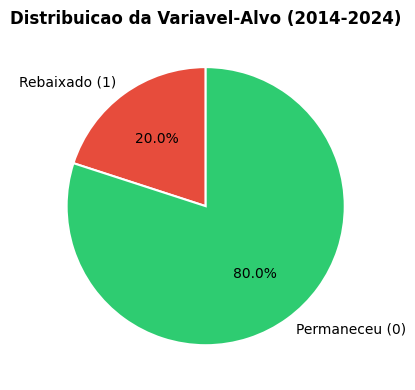

In [13]:
# Criacao da variavel dependente binaria (feito em Python)
# Convencao estatistica da regressao logistica:
#   1 = Rebaixado  -> evento de interesse (o que o modelo preve)
#   0 = Permaneceu -> categoria de referencia
df["Status_bin"] = df["Situacao"].apply(lambda x: 1 if str(x).strip().lower() == "rebaixado" else 0)

print("Distribuicao da variavel dependente (Status_bin):")
print(df["Status_bin"].value_counts().rename({1: "Rebaixado (1)", 0: "Permaneceu (0)"}))

# Grafico de pizza
fig, ax = plt.subplots(figsize=(5, 4))
n_reb = (df[df["Temporada"] < 2025]["Status_bin"] == 1).sum()
n_per = (df[df["Temporada"] < 2025]["Status_bin"] == 0).sum()
ax.pie(
    [n_reb, n_per],
    labels=["Rebaixado (1)", "Permaneceu (0)"],
    autopct="%1.1f%%",
    colors=["#e74c3c", "#2ecc71"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
ax.set_title("Distribuicao da Variavel-Alvo (2014-2024)", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join("..", "img", "distribuicao_status_bin.png"), dpi=150)
plt.show()

## Como os Pontos e a Situacao foram gerados

Os **pontos finais** e a **situacao de cada clube** (Rebaixado, Top4, SerieA) sao obtidos diretamente via scraping da tabela de classificacao final do Transfermarkt, pela funcao `coletar_pontos_temporada()`.

A **posicao na tabela** determina automaticamente a `Situacao`:
- Posicao 1–4 → `Top4`
- Posicao 5–16 → `SerieA`
- Posicao 17–20 → `Rebaixado`

Casos onde a posicao no Transfermarkt nao refletiu a situacao real (decisoes judiciais, recursos) foram corrigidos manualmente na celula de Limpeza 2, diretamente em Python.

Para a temporada de **2025**, `Pontos` e `Situacao` permanecem `NaN` pois o campeonato esta em andamento. O modelo de previsao utiliza apenas as features de plantel e valor de mercado, disponiveis antes do inicio da temporada.

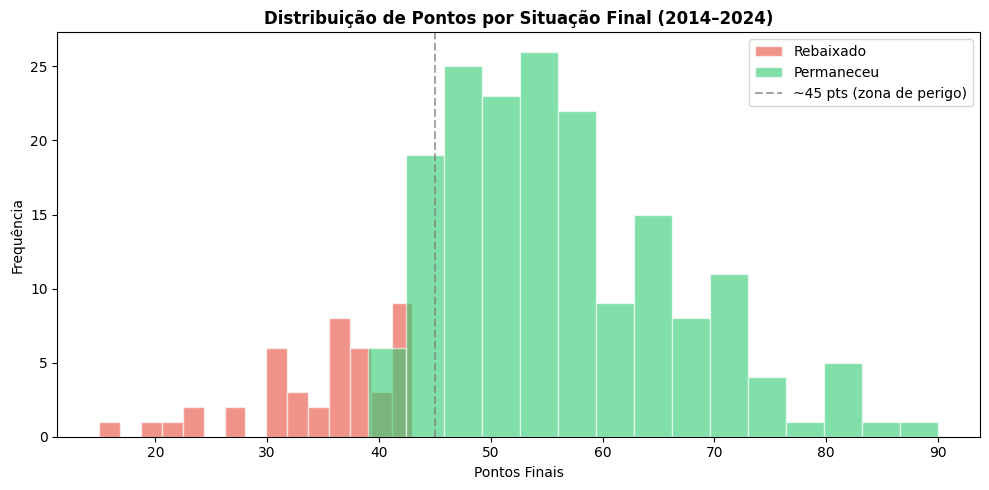

In [14]:
# Distribuição de pontos por situação final (excluindo 2025, sem dados)
df_hist = df[df['Temporada'] < 2025].copy()

fig, ax = plt.subplots(figsize=(10, 5))

for status, label, cor in [(1, 'Rebaixado', '#e74c3c'), (0, 'Permaneceu', '#2ecc71')]:
    dados = df_hist[df_hist['Status_bin'] == status]['Pontos'].dropna()
    ax.hist(dados, bins=15, alpha=0.6, label=label, color=cor, edgecolor='white')

ax.axvline(x=45, color='gray', linestyle='--', alpha=0.7, label='~45 pts (zona de perigo)')
ax.set_xlabel('Pontos Finais')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição de Pontos por Situação Final (2014–2024)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join('..', 'img', 'pontos_por_situacao.png'), dpi=150)
plt.show()

## Etapa 4 — Coleta do Desempenho Histórico por Temporada (V, E, D, Gols, SG, Pts)

Para implementar **janelas deslizantes** (*sliding windows*) — uma das melhorias metodológicas recomendadas — precisamos do histórico de desempenho **por clube por temporada**: vitórias, empates, derrotas, gols marcados, gols sofridos, saldo de gols e pontos.

Esses dados também vêm da **tabela de classificação final** do Transfermarkt, mas agora coletamos **todas** as colunas da tabela, não apenas pontos:

| Coluna coletada | Descrição |
|---|---|
| `Posicao` | Posição final na tabela |
| `V` | Vitórias |
| `E` | Empates |
| `D` | Derrotas |
| `Gols_Pro` | Gols marcados |
| `Gols_Contra` | Gols sofridos |
| `SG` | Saldo de gols |
| `Pts` | Pontos finais |
| `Aproveitamento` | Pts / (3 × Jogos) × 100 |

> **Por que não incluir 2025?** A previsão é justamente para 2025 — o modelo precisa prever quem será rebaixado nesta temporada. Incluir dados de 2025 seria *data leakage*: o campeonato ainda está em andamento e não há resultado final disponível.

**Intervalo coletado: 2014–2024** (11 temporadas × 20 clubes = 220 registros)

### Estrutura HTML da tabela no Transfermarkt

A tabela de classificação (`class="items"`) possui 10 colunas por linha:

```
td[0] = Posição   td[1] = Escudo (vazio)   td[2] = Clube
td[3] = Jogos     td[4] = V                td[5] = E
td[6] = D         td[7] = Gols ("XX:YY")   td[8] = SG    td[9] = Pts
```

URL padrão:
```
https://www.transfermarkt.com.br/campeonato-brasileiro-serie-a/tabelle/wettbewerb/BRA1?saison_id={ano - 1}
```

In [15]:
def coletar_desempenho_temporada(ano: int) -> pd.DataFrame:
    """
    Raspa a tabela de classificação final do Transfermarkt para uma temporada.

    Retorna um DataFrame com: Temporada, Posicao, Clube, Jogos, V, E, D,
    Gols_Pro, Gols_Contra, SG, Pts, Aproveitamento.

    Estrutura dos TDs confirmada inspecionando o HTML:
      td[0]=Posicao  td[1]=escudo(vazio)  td[2]=Clube  td[3]=Jogos
      td[4]=V  td[5]=E  td[6]=D  td[7]=Gols("XX:YY")  td[8]=SG  td[9]=Pts

    Nao coleta 2025 pois o campeonato esta em andamento (seria data leakage).
    """
    url = (
        "https://www.transfermarkt.com.br/campeonato-brasileiro-serie-a/"
        f"tabelle/wettbewerb/BRA1?saison_id={ano - 1}"
    )
    resp = requests.get(url, headers=HEADERS, timeout=20)
    soup = BeautifulSoup(resp.text, "html.parser")

    tabela = soup.find("table", {"class": "items"})
    if tabela is None:
        print(f"  [AVISO] Tabela nao encontrada para {ano}")
        return pd.DataFrame()

    tbody = tabela.find("tbody")
    linhas = tbody.find_all("tr") if tbody else []
    registros = []

    for tr in linhas:
        tds = tr.find_all("td")
        if len(tds) < 10:
            continue
        try:
            posicao     = int(tds[0].get_text(strip=True))
            clube       = normalizar_nome(tds[2].get_text(strip=True))
            jogos       = int(tds[3].get_text(strip=True))
            v           = int(tds[4].get_text(strip=True))
            e           = int(tds[5].get_text(strip=True))
            d           = int(tds[6].get_text(strip=True))
            gols_txt    = tds[7].get_text(strip=True)   # formato "67:38"
            sg          = int(tds[8].get_text(strip=True))
            pts         = int(tds[9].get_text(strip=True))

            gols_pro, gols_contra = (int(x) for x in gols_txt.split(":"))

            registros.append({
                "Temporada":      ano,
                "Posicao":        posicao,
                "Clube":          clube,
                "Jogos":          jogos,
                "V":              v,
                "E":              e,
                "D":              d,
                "Gols_Pro":       gols_pro,
                "Gols_Contra":    gols_contra,
                "SG":             sg,
                "Pts":            pts,
                "Aproveitamento": round(pts / (3 * jogos) * 100, 1) if jogos > 0 else None,
            })
        except (ValueError, IndexError) as err:
            print(f"  [linha ignorada] {err}")
            continue

    time.sleep(2)
    return pd.DataFrame(registros)

print("Funcao coletar_desempenho_temporada definida.")

Funcao coletar_desempenho_temporada definida.


### Execução — Coleta de 2014 a 2024 e salvamento em Excel

O arquivo gerado (`tabela_desempenho_brasileirao.xlsx`) contém:
- **Aba `Desempenho_XXXX`**: dados brutos de cada temporada (para inspeção visual)
- **Aba `Todos`**: todas as temporadas consolidadas em um único DataFrame

In [16]:
if EXECUTAR_COLETA:
    frames_desemp = []
    caminho_desemp = os.path.join("..", "dados", "tabela_desempenho_brasileirao.xlsx")

    print("=== Coletando desempenho por temporada (2014-2024) ===")
    print("Nao inclui 2025 — campeonato em andamento (evita data leakage)\n")

    with pd.ExcelWriter(caminho_desemp, engine="openpyxl") as writer:
        for ano in range(2014, 2025):   # 2014 a 2024 inclusive — SEM 2025
            print(f"  [{ano}] raspando...", end=" ")
            df_ano = coletar_desempenho_temporada(ano)
            frames_desemp.append(df_ano)
            df_ano.to_excel(writer, sheet_name=f"Desempenho_{ano}", index=False)
            print(f"{len(df_ano)} clubes coletados")

        # Aba consolidada com todas as temporadas
        df_desemp_total = pd.concat(frames_desemp, ignore_index=True)
        df_desemp_total.to_excel(writer, sheet_name="Todos", index=False)

    print(f"\nSalvo em: {caminho_desemp}")
    print(f"Total: {len(df_desemp_total)} registros | "
          f"Temporadas: {sorted(df_desemp_total['Temporada'].unique())}")
else:
    print("EXECUTAR_COLETA = False — lendo arquivo existente...")
    caminho_desemp = os.path.join("..", "dados", "tabela_desempenho_brasileirao.xlsx")
    df_desemp_total = pd.read_excel(caminho_desemp, sheet_name="Todos")
    print(f"Carregado: {len(df_desemp_total)} registros")

=== Coletando desempenho por temporada (2014-2024) ===
Nao inclui 2025 — campeonato em andamento (evita data leakage)

  [2014] raspando... 20 clubes coletados
  [2015] raspando... 20 clubes coletados
  [2016] raspando... 20 clubes coletados
  [2017] raspando... 20 clubes coletados
  [2018] raspando... 20 clubes coletados
  [2019] raspando... 20 clubes coletados
  [2020] raspando... 20 clubes coletados
  [2021] raspando... 20 clubes coletados
  [2022] raspando... 20 clubes coletados
  [2023] raspando... 20 clubes coletados
  [2024] raspando... 20 clubes coletados

Salvo em: ..\dados\tabela_desempenho_brasileirao.xlsx
Total: 220 registros | Temporadas: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [17]:
# Verificacao e visualizacao dos dados coletados
print("Amostra — temporada 2024 (classificacao final):\n")
df_2024_desemp = df_desemp_total[df_desemp_total["Temporada"] == 2024].copy()
display(df_2024_desemp[["Posicao","Clube","V","E","D","Gols_Pro","Gols_Contra","SG","Pts","Aproveitamento"]])

print(f"\nEstatisticas descritivas (2014-2024):")
display(df_desemp_total[["V","E","D","Gols_Pro","Gols_Contra","SG","Pts","Aproveitamento"]].describe().round(2))

Amostra — temporada 2024 (classificacao final):



,Posicao,Clube,V,E,D,Gols_Pro,Gols_Contra,SG,Pts,Aproveitamento
200,1,Botafogo,23,10,5,59,29,30,79,69.3
201,2,Palmeiras,22,7,9,60,33,27,73,64.0
202,3,Flamengo,20,10,8,61,42,19,70,61.4
203,4,Fortaleza,19,11,8,53,39,14,68,59.6
204,5,Internacional,18,11,9,53,36,17,65,57.0
205,6,Sao Paulo,17,8,13,53,43,10,59,51.8
206,7,Corinthians,15,11,12,54,45,9,56,49.1
207,8,Bahia,15,8,15,49,49,0,53,46.5
208,9,Cruzeiro,14,10,14,43,41,2,52,45.6
209,10,Vasco da Gama,14,8,16,43,56,-13,50,43.9



Estatisticas descritivas (2014-2024):


,V,E,D,Gols_Pro,Gols_Contra,SG,Pts,Aproveitamento
count,220.00,220.00,220.00,220.00,220.00,220.00,220.00,220.00
mean,13.92,10.15,13.92,44.82,44.82,0.00,51.91,45.55
std,4.49,2.45,4.41,10.89,9.48,16.82,12.93,11.35
min,1.00,4.00,3.00,18.00,24.00,-44.00,15.00,13.20
25%,11.00,8.00,11.00,38.00,38.00,-10.00,43.75,38.38
50%,14.00,10.00,14.00,44.00,44.00,0.00,51.50,45.15
75%,17.00,12.00,17.00,51.25,50.25,11.25,59.25,52.00
max,28.00,17.00,25.00,86.00,81.00,49.00,90.00,78.90


## Conclusão da Coleta

A base de dados está consolidada e pronta para análise. Resumo:

### BASE_FINAL.xlsx (elencos + rótulos)
- **240 registros** no total (20 clubes × 12 temporadas: 2014–2025)
- **220 registros com rótulo definido** (2014–2024, utilizados em treino/teste)
- **20 registros de previsão** (temporada 2025, sem resultado)
- **3 features** de elenco: `Plantel`, `Estrangeiros`, `Valor de Mercado Total`
- **1 variável-alvo** binária: `Status_bin` (0 = Permaneceu, 1 = Rebaixado)

### tabela_desempenho_brasileirao.xlsx (desempenho por temporada) — **novo**
- **220 registros** (20 clubes × 11 temporadas: 2014–2024, **sem 2025**)
- **Colunas coletadas:** `V`, `E`, `D`, `Gols_Pro`, `Gols_Contra`, `SG`, `Pts`, `Aproveitamento`
- **Finalidade:** calcular **janelas deslizantes** (*sliding windows*) com médias das últimas 3 e 5 temporadas de cada clube, enriquecendo as features do modelo nas próximas etapas

Os dados estão prontos para a etapa de **Análise Exploratória** (`01_analise_exploratoria.ipynb`).